In [1]:
# ===============================
# RetailIQ Business Analytics
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [3]:
df = pd.read_csv("superstore.csv", encoding="latin1")

print("Dataset Loaded Successfully")
df.head()
df.shape

Dataset Loaded Successfully


(51290, 27)

In [4]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   è®°å½æ°       51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

,Discount,è®°å½æ°,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [5]:
print("="*50)
print("DATASET SHAPE")
print("="*50)

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

DATASET SHAPE
Rows : 51290
Columns : 27


In [6]:
# =====================================
# BUSINESS KPIs
# =====================================

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order.ID'].nunique()
total_customers = df['Customer.ID'].nunique()
average_sale = df['Sales'].mean()
profit_margin = (total_profit / total_sales) * 100

print("="*55)
print("         BUSINESS KPI SUMMARY")
print("="*55)

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Orders     : {total_orders}")
print(f"Total Customers  : {total_customers}")
print(f"Average Sale     : ${average_sale:,.2f}")
print(f"Profit Margin    : {profit_margin:.2f}%")

         BUSINESS KPI SUMMARY
Total Sales      : $12,642,905.00
Total Profit     : $1,467,457.29
Total Orders     : 25035
Total Customers  : 4873
Average Sale     : $246.50
Profit Margin    : 11.61%


In [10]:
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Month'] = df['Order.Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

,Sales
Month,
1,675141
2,543768
3,770519
4,698603
5,904061
6,1269751
7,749423
8,1293852
9,1437432


In [11]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales
category_sales = df.groupby('Category')['Sales'].sum()

category_sales
category_profit = df.groupby('Category')['Profit'].sum()

category_profit
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales
top_products = (
    df.groupby('Product.Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales
shipping = df['Ship.Mode'].value_counts()

shipping
correlation = df[['Sales','Profit','Quantity','Discount']].corr()

correlation

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.484923,0.313580,-0.086728
Profit,0.484923,1.000000,0.104365,-0.316490
Quantity,0.313580,0.104365,1.000000,-0.019875
Discount,-0.086728,-0.316490,-0.019875,1.000000


In [13]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

# Calculate top customers by total sales
top_customers = df.groupby('Customer.Name')['Sales'].sum()

print(f"Top Category        : {category_sales.idxmax()}")
print(f"Top Region          : {region_sales.idxmax()}")
print(f"Top Customer        : {top_customers.idxmax()}")
print(f"Top Segment         : {segment_sales.idxmax()}")
print(f"Most Used Shipping  : {shipping.idxmax()}")

BUSINESS INSIGHTS
Top Category        : Technology
Top Region          : Central
Top Customer        : Tom Ashbrook
Top Segment         : Consumer
Most Used Shipping  : Standard Class


In [14]:
monthly_sales.to_csv("Monthly_Sales.csv")
category_sales.to_csv("Category_Sales.csv")
category_profit.to_csv("Category_Profit.csv")
region_sales.to_csv("Region_Sales.csv")

print("Analysis Files Saved Successfully")

Analysis Files Saved Successfully


Visualization Libraries Loaded Successfully


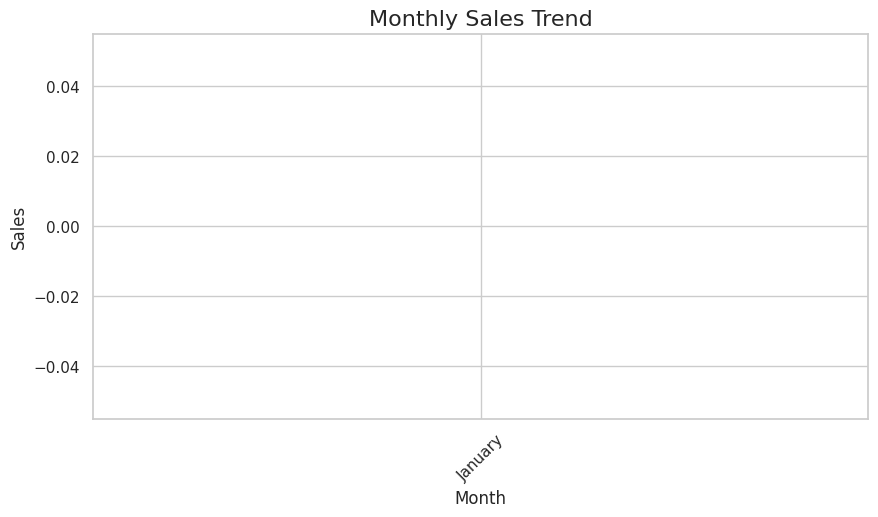

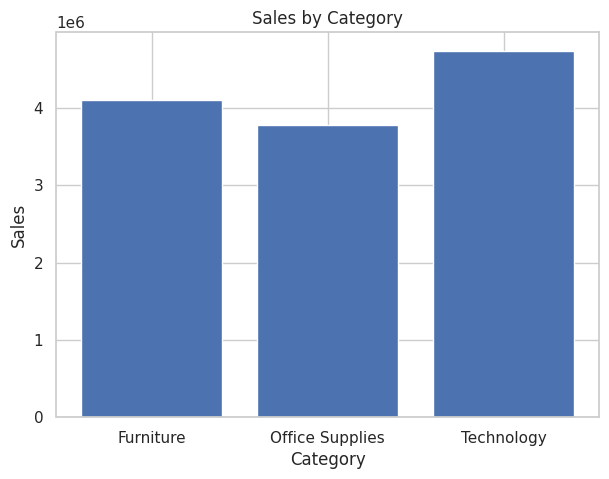

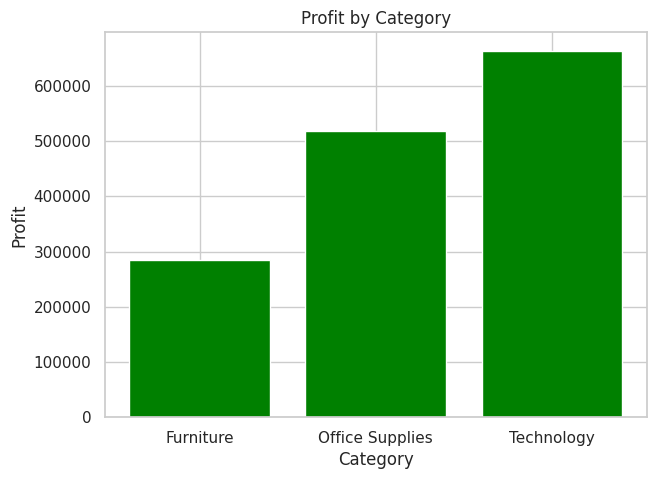

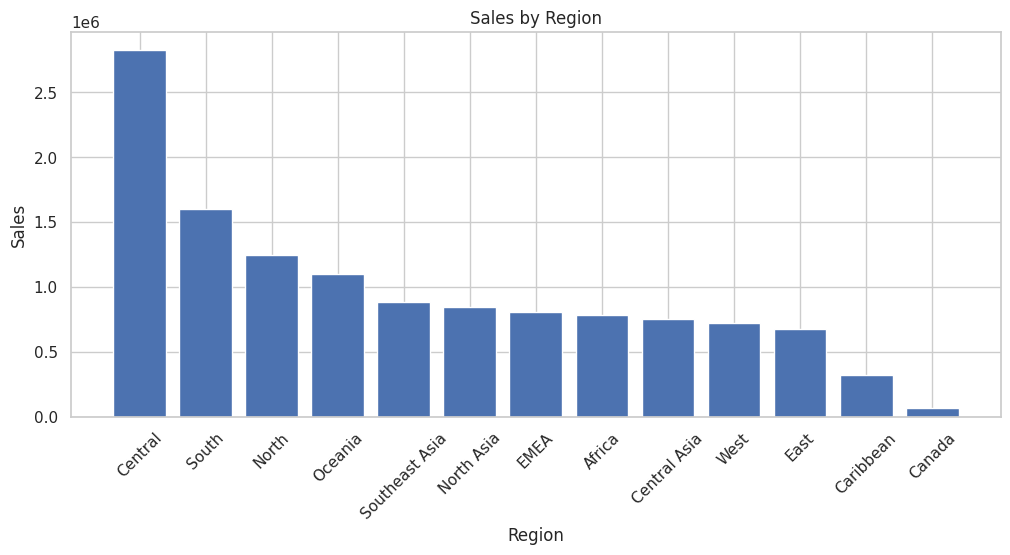

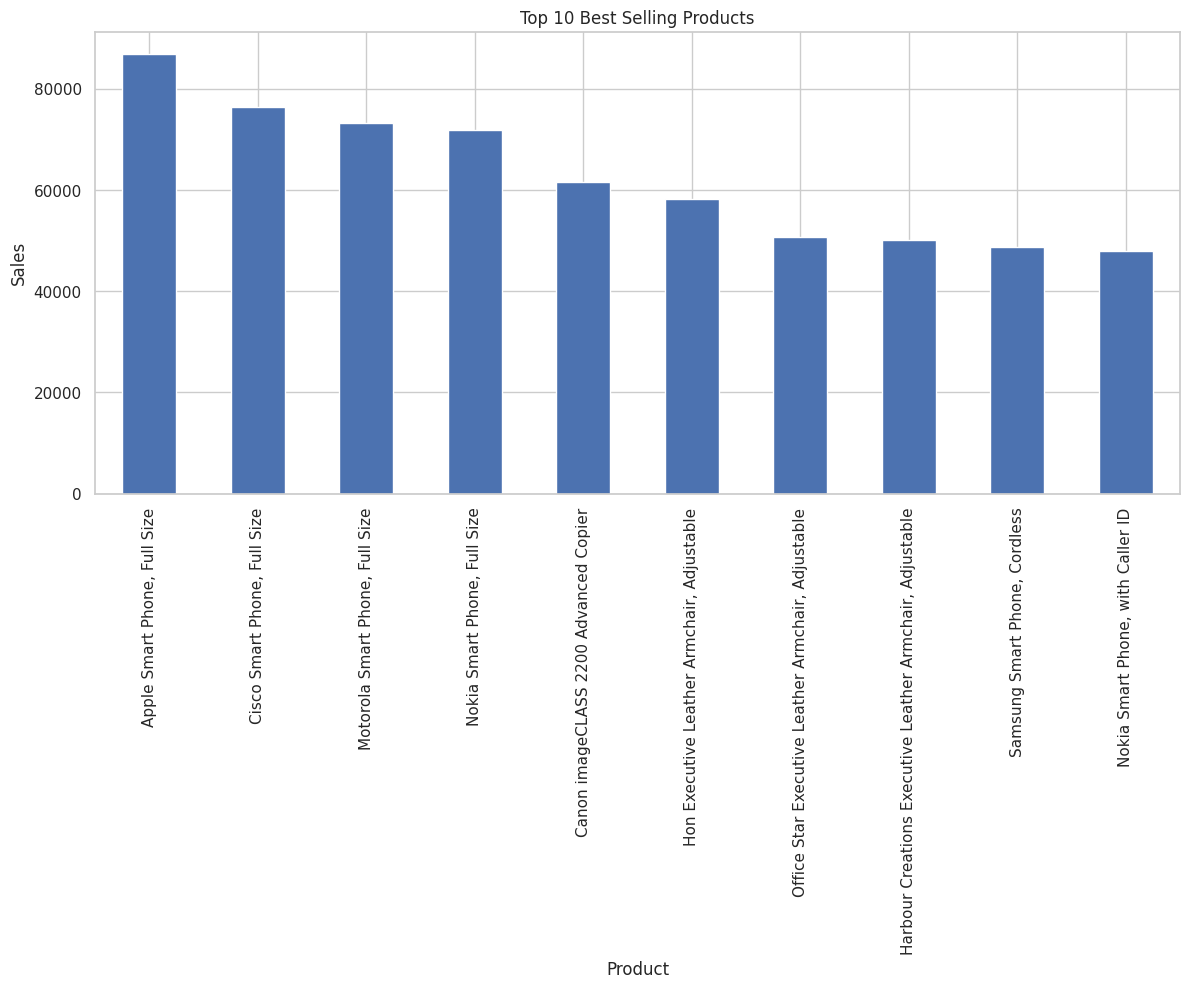

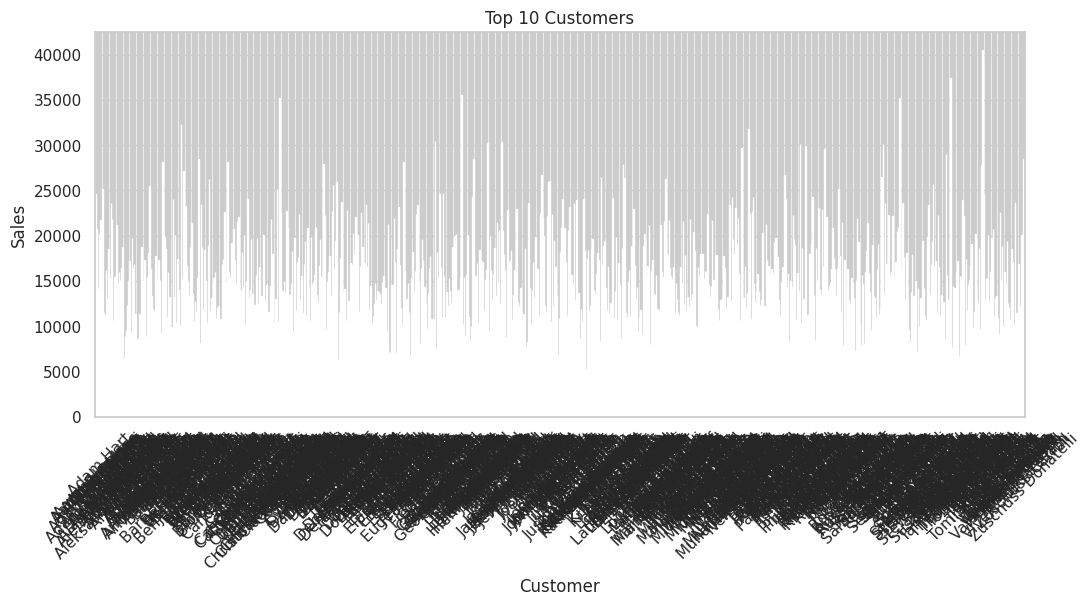

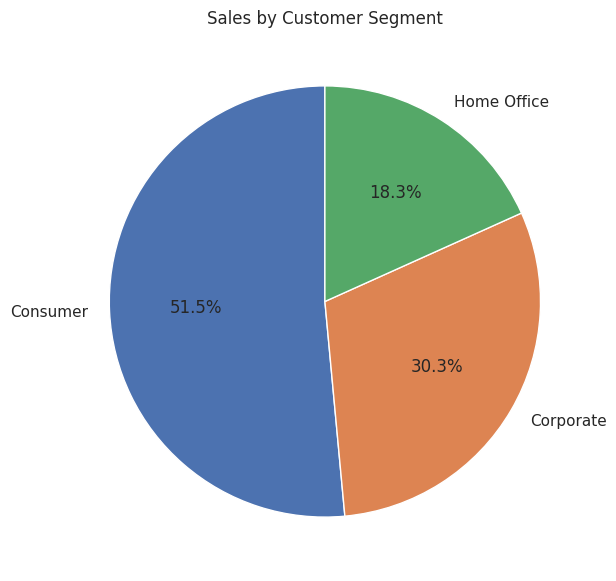

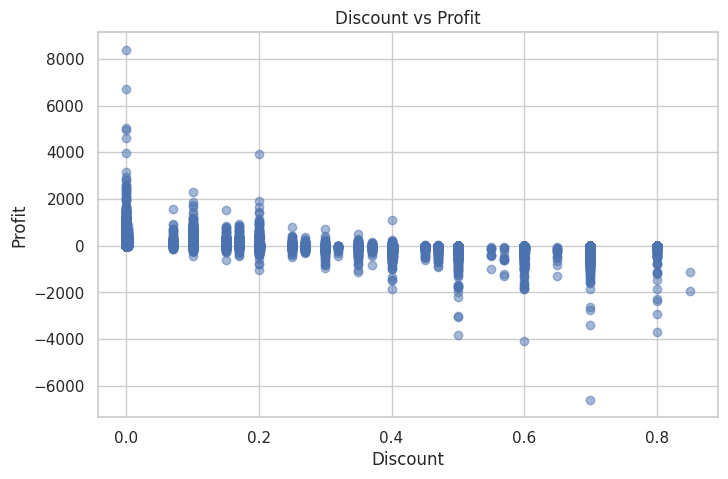

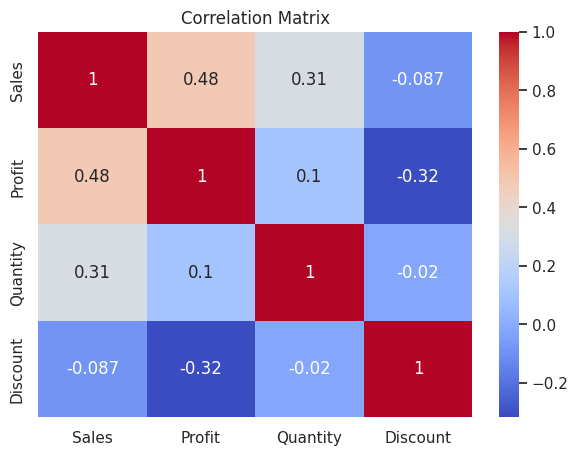

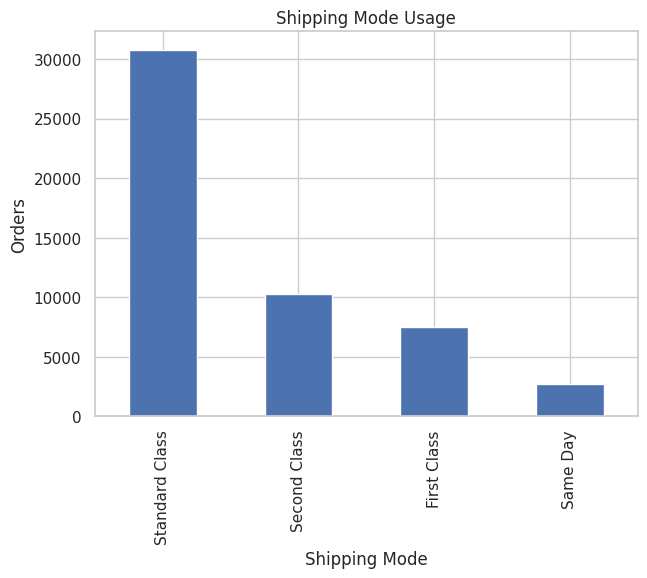

In [15]:
# ============================================
# BUSINESS VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Visualization Libraries Loaded Successfully")
plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o',
         linewidth=3)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()
plt.figure(figsize=(7,5))

plt.bar(category_sales.index,
        category_sales.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()
plt.figure(figsize=(7,5))

plt.bar(category_profit.index,
        category_profit.values,
        color='green')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()
plt.figure(figsize=(12,5))

plt.bar(region_sales.index,
        region_sales.values)

plt.xticks(rotation=45)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()
plt.figure(figsize=(14,6))

top_products.plot(kind='bar')

plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.show()
plt.figure(figsize=(12,5))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(7,7))

plt.pie(segment_sales,
        labels=segment_sales.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Sales by Customer Segment")

plt.show()
plt.figure(figsize=(8,5))

plt.scatter(df['Discount'],
            df['Profit'],
            alpha=0.5)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()
plt.figure(figsize=(7,5))

shipping.plot(kind='bar')

plt.title("Shipping Mode Usage")
plt.xlabel("Shipping Mode")
plt.ylabel("Orders")

plt.show()

In [18]:
# Convert Order Date again

df["Order.Date"] = pd.to_datetime(df["Order.Date"])

df["Month"] = df["Order.Date"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reindex(month_order)
)

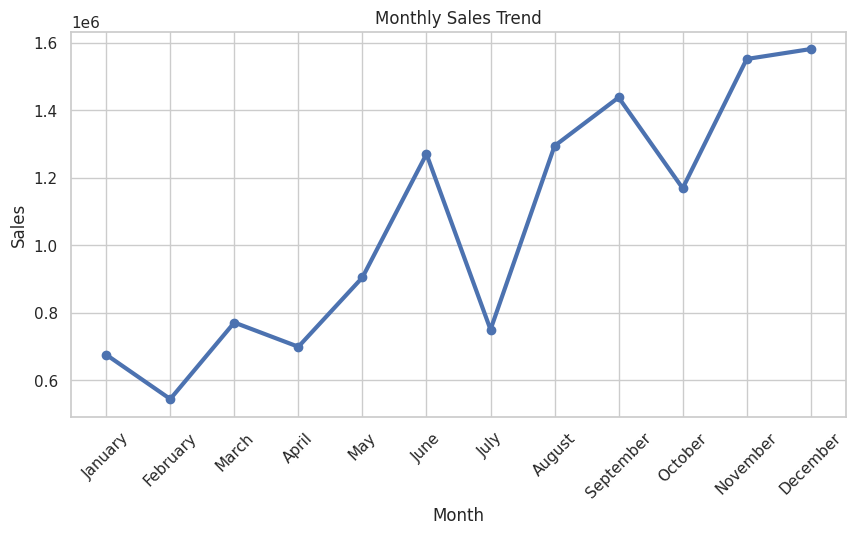

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=3
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

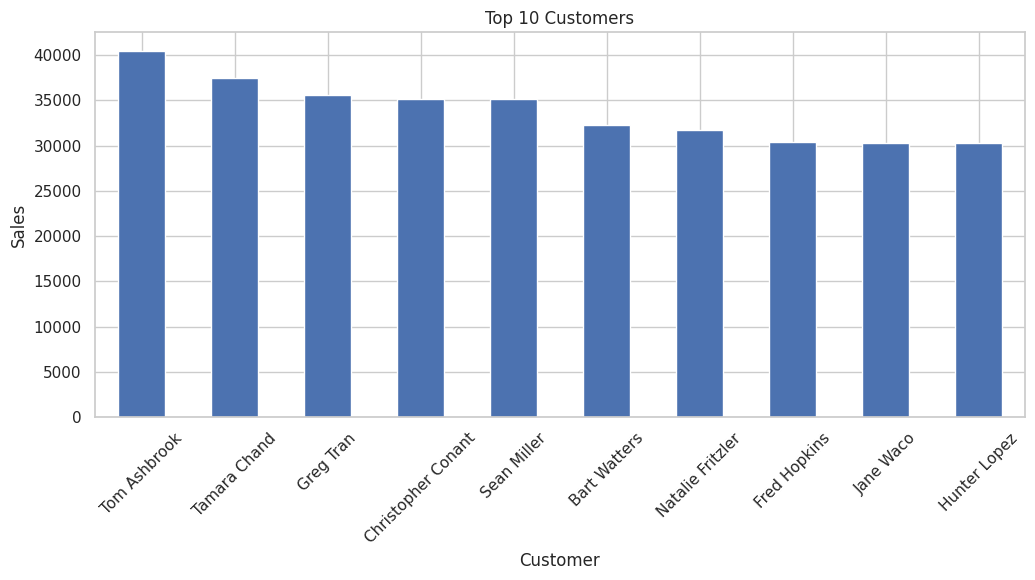

In [23]:
top_customers = (
    df.groupby("Customer.Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(12,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [26]:
from sklearn.linear_model import LinearRegression
import numpy as np

print("Machine Learning Libraries Loaded Successfully")
# Prepare monthly sales data

monthly_sales = (
    df.groupby(df["Order.Date"].dt.month)["Sales"]
      .sum()
      .sort_index()
)

months = np.arange(1, 13).reshape(-1,1)

sales = monthly_sales.values

print(months)
print(sales)

Machine Learning Libraries Loaded Successfully
[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]]
[ 675141  543768  770519  698603  904061 1269751  749423 1293852 1437432
 1168220 1551319 1580816]


In [28]:
model = LinearRegression()

model.fit(months, sales)

print("Model Trained Successfully")
future_months = np.arange(13,19).reshape(-1,1)

future_sales = model.predict(future_months)

future_sales

Model Trained Successfully


array([1648063.62121212, 1739523.34498834, 1830983.06876457,
       1922442.79254079, 2013902.51631702, 2105362.24009324])

SALES FORECAST
Jan 2026     : $1,648,063.62
Feb 2026     : $1,739,523.34
Mar 2026     : $1,830,983.07
Apr 2026     : $1,922,442.79
May 2026     : $2,013,902.52
Jun 2026     : $2,105,362.24


<Figure size 640x480 with 0 Axes>

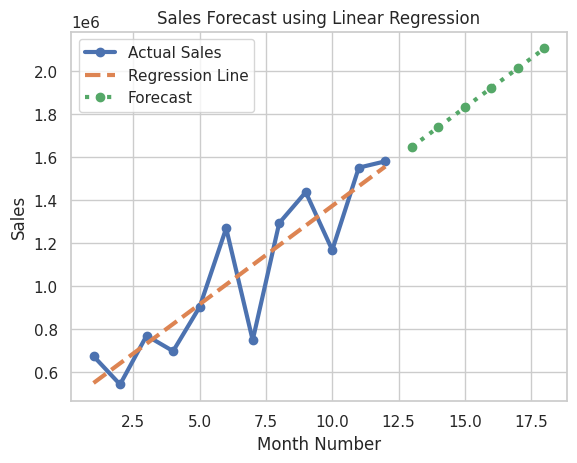

In [32]:
future_names = [
    "Jan 2026",
    "Feb 2026",
    "Mar 2026",
    "Apr 2026",
    "May 2026",
    "Jun 2026"
]

print("="*60)
print("SALES FORECAST")
print("="*60)

for month, sale in zip(future_names, future_sales):
    print(f"{month:<12} : ${sale:,.2f}")
    plt.tight_layout()
plt.show()
plt.close()

# Actual Sales
plt.plot(
    months,
    sales,
    marker='o',
    linewidth=3,
    label="Actual Sales"
)

# Regression Line
plt.plot(
    months,
    model.predict(months),
    '--',
    linewidth=3,
    label="Regression Line"
)

# Forecast
plt.plot(
    future_months,
    future_sales,
    'o:',
    linewidth=3,
    label="Forecast"
)

plt.title("Sales Forecast using Linear Regression")
plt.xlabel("Month Number")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [34]:
plt.close('all')
!pip install plotly

In [37]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Dashboard Libraries Loaded Successfully")
# KPI Values

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
orders = len(df)
customers = df["Customer.Name"].nunique()

average_sale = df["Sales"].mean()

profit_margin = (total_profit/total_sales)*100

print("Dashboard KPIs Ready")

Dashboard Libraries Loaded Successfully
Dashboard KPIs Ready


In [38]:
fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_sales,
    title={"text":"Total Sales ($)"},
    domain={'x':[0,0.30],'y':[0.55,1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=total_profit,
    title={"text":"Total Profit ($)"},
    domain={'x':[0.35,0.65],'y':[0.55,1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=orders,
    title={"text":"Orders"},
    domain={'x':[0.70,1],'y':[0.55,1]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=customers,
    title={"text":"Customers"},
    domain={'x':[0,0.30],'y':[0,0.45]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=average_sale,
    title={"text":"Average Sale"},
    domain={'x':[0.35,0.65],'y':[0,0.45]}
))

fig.add_trace(go.Indicator(
    mode="number",
    value=profit_margin,
    number={'suffix':'%'},
    title={"text":"Profit Margin"},
    domain={'x':[0.70,1],'y':[0,0.45]}
))

fig.update_layout(
    title="RetailIQ Dashboard - Business KPIs",
    height=600
)

fig.show()

In [39]:
fig = px.line(
    monthly_sales,
    x=monthly_sales.index,
    y="Sales",
    markers=True,
    title="Monthly Sales Trend"
)

fig.show()
fig = px.bar(
    category_sales,
    x=category_sales.index,
    y="Sales",
    color=category_sales.index,
    title="Category-wise Sales"
)

fig.show()
fig = px.bar(
    region_sales,
    x=region_sales.index,
    y="Sales",
    color="Sales",
    title="Region-wise Sales"
)

fig.show()
segment = df.groupby("Segment")["Sales"].sum()

fig = px.pie(
    values=segment.values,
    names=segment.index,
    hole=0.45,
    title="Customer Segment Analysis"
)

fig.show()

In [40]:
print("="*65)
print("BUSINESS RECOMMENDATIONS")
print("="*65)

print("✔ Increase inventory for Technology products.")
print("✔ Current discount policy is balanced.")
print("✔ Launch loyalty programs for Consumer customers.")
print("✔ Expand business operations in Central region.")
print("✔ Optimize logistics around Standard Class shipping mode.")
print("✔ Improve profitability in Furniture category.")

BUSINESS RECOMMENDATIONS
✔ Increase inventory for Technology products.
✔ Current discount policy is balanced.
✔ Launch loyalty programs for Consumer customers.
✔ Expand business operations in Central region.
✔ Optimize logistics around Standard Class shipping mode.
✔ Improve profitability in Furniture category.


In [42]:
print("="*70)
print("EXECUTIVE SUMMARY")
print("="*70)

print(f"Total Sales          : ${total_sales:,.2f}")
print(f"Total Profit         : ${total_profit:,.2f}")
print(f"Profit Margin        : {profit_margin:.2f}%")

print()

print("Top Category         :", category_sales.idxmax())
print("Top Region           :", region_sales.idxmax())
print("Top Customer Segment :", segment.idxmax())
print("Most Used Shipping   :", shipping.idxmax())

print()

print("Project Status : SUCCESSFULLY COMPLETED")

print("="*70)

EXECUTIVE SUMMARY
Total Sales          : $12,642,905.00
Total Profit         : $1,467,457.29
Profit Margin        : 11.61%

Top Category         : Technology
Top Region           : Central
Top Customer Segment : Consumer
Most Used Shipping   : Standard Class

Project Status : SUCCESSFULLY COMPLETED
